In [12]:
from Autograd import Tensor
from Activation import ReLU
from Loss import mean_squared_error,cross_entropy_loss
from Training import training
from Model import Sequential,Linear,Layernorm
from Optimiser import SGD,Momentum,RMSProp,Adagrad,Adadelta,Adam
from Testing import non_hot_one_accuracy
import numpy as np
import matplotlib.pyplot as plt
import copy 

In previous models, I used full-batch or mini-batch stochastic gradient descent. Whilst these will work well for convex loss functions (due to the local minimum also being the global minimum), for non convex functions, we may get 'stuck' at local minima. 

Momentum takes into account the previous gradients; for example, if there is a sign change in the gradient due to a local minima, the 'velocity' could still be positive hence we can move past the local minimum.

Adagrad aims to adjust the update rule for different components depending on the history of the updates. If a certain parameter has had many large updates, it implies it is sensitive to change so the updates should be adjusted for that parameter. It does this by accumulation of the squared gradients to get a measure of the parameters sensitivity to change. 

RMSProp takes the same idea as Adagrad and improves on it. In particular, Adagrad was developed in the context of convex optimisation; the learning rate could decay very aggressively in non convex contexts which could result in getting stuck at local minima. RMSProp doesn't allow the state vector to grow uncontrollably large, hence the updates don't become too small too quickly.

Adadelta is another variation of Adagrad, which aims to adapt the learning rate of each parameter through each iteration.

Adam is a combination of the above techniques in one optimisation algorithm.

In [79]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_digits

digits=load_digits()

coords=digits.data
classes=digits.target

coords_train,coords_test,class_train,class_test=train_test_split(coords,classes,test_size=0.2,random_state=42)
coords_train,coords_test,class_train,class_test=Tensor(coords_train),Tensor(coords_test),Tensor(class_train),Tensor(class_test)

no_classes=10
no_samples=coords.shape[0]
no_features=coords.shape[1]

The image data set is a classification problem where depending on the 8 by 8 matrix (representing the image of the number), we need to deduce which number from 0 to 9 it is.

In [104]:
loss_fn=cross_entropy_loss
epochs=250
batch_size=32

initial=Sequential([Linear(no_features,64),ReLU(),Linear(64,32),ReLU(),Linear(32,no_classes)])

SGD_model=copy.deepcopy(initial)
optimiser=SGD(SGD_model.parameters(),lr=0.05)
SGDloss=training(coords_train,SGD_model,class_train,loss_fn,epochs,optimiser,batch_size)

Momentum_model=copy.deepcopy(initial)
optimiser=Momentum(Momentum_model.parameters(),lr=0.005,beta=0.9)
Momentumloss=training(coords_train,Momentum_model,class_train,loss_fn,epochs,optimiser,batch_size)

Adagrad_model=copy.deepcopy(initial)
optimiser=Adagrad(Adagrad_model.parameters(),lr=0.05,eta=0.9)
Adagradloss=training(coords_train,Adagrad_model,class_train,loss_fn,epochs,optimiser,batch_size)

RMSProp_model=copy.deepcopy(initial)
optimiser=RMSProp(RMSProp_model.parameters(),lr=0.001,gamma=0.9)
RMSProploss=training(coords_train,RMSProp_model,class_train,loss_fn,epochs,optimiser,batch_size)

Adadelta_model=copy.deepcopy(initial)
optimiser=Adadelta(Adadelta_model.parameters(),rho=0.95)
Adadeltaloss=training(coords_train,Adadelta_model,class_train,loss_fn,epochs,optimiser,batch_size)

Adam_model=copy.deepcopy(initial)
optimiser=Adam(Adam_model.parameters(),lr=0.005,beta1=0.9,beta2=0.999)
Adamloss=training(coords_train,Adam_model,class_train,loss_fn,epochs,optimiser,batch_size)

As its a classification problem, i use cross entropy loss as the loss function. I use copies of the initial model as there won't be any difference in the initialisation of the parameters for each model.

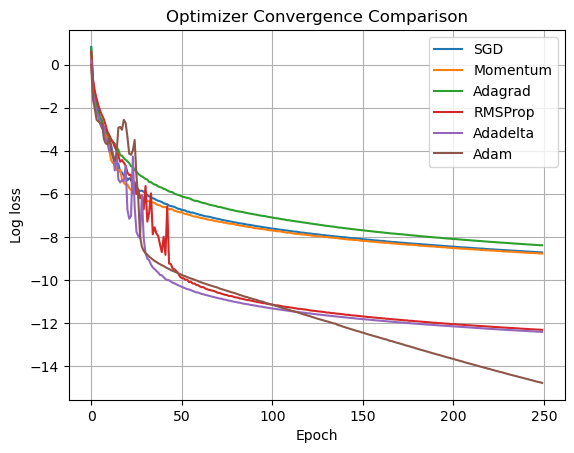

In [105]:
plt.plot(np.log(SGDloss),label="SGD")
plt.plot(np.log(Momentumloss),label="Momentum")
plt.plot(np.log(Adagradloss),label="Adagrad")
plt.plot(np.log(RMSProploss),label="RMSProp")
plt.plot(np.log(Adadeltaloss),label="Adadelta")
plt.plot(np.log(Adamloss),label="Adam")

plt.xlabel("Epoch")
plt.ylabel("Log loss")
plt.title("Optimizer Convergence Comparison")

plt.legend()
plt.grid(True)

plt.show()

After 250 epochs, it is clear which optimiser has the lowest loss, indicating faster convergence. The training final loss and accuracy clearly demonstrate that we have fit the model to the data, potentially overfitting.

In [106]:
print("SGD final training loss and accuracy: ",SGDloss[-1],non_hot_one_accuracy(SGD_model.forward_prop(coords_train),class_train))
print("Momentum final training loss and accuracy: ",Momentumloss[-1],non_hot_one_accuracy(Momentum_model.forward_prop(coords_train),class_train))
print("Adagrad final training loss and accuracy: ",Adagradloss[-1],non_hot_one_accuracy(Adagrad_model.forward_prop(coords_train),class_train))
print("RMSProp final training loss and accuracy: ",RMSProploss[-1],non_hot_one_accuracy(RMSProp_model.forward_prop(coords_train),class_train))
print("Adadelta final training loss and accuracy: ",Adadeltaloss[-1],non_hot_one_accuracy(Adadelta_model.forward_prop(coords_train),class_train))
print("Adam final training loss and accuracy: ",Adamloss[-1],non_hot_one_accuracy(Adam_model.forward_prop(coords_train),class_train))

SGD final training loss and accuracy:  0.00016256696374828276 1.0
Momentum final training loss and accuracy:  0.0001542337011360827 1.0
Adagrad final training loss and accuracy:  0.00022642732371405368 1.0
RMSProp final training loss and accuracy:  4.4634697283979666e-06 1.0
Adadelta final training loss and accuracy:  4.051150691230679e-06 1.0
Adam final training loss and accuracy:  3.7888354378896365e-07 1.0


In [107]:
SGDtest=SGD_model.forward_prop(coords_test)
Momentumtest=Momentum_model.forward_prop(coords_test)
Adagradtest=Adagrad_model.forward_prop(coords_test)
RMSProptest=RMSProp_model.forward_prop(coords_test)
Adadeltatest=Adadelta_model.forward_prop(coords_test)
Adamtest=Adam_model.forward_prop(coords_test)

SGDLoss=cross_entropy_loss(SGDtest,class_test)
MomentumLoss=cross_entropy_loss(Momentumtest,class_test)
AdagradLoss=cross_entropy_loss(Adagradtest,class_test)
RMSPropLoss=cross_entropy_loss(RMSProptest,class_test)
AdadeltaLoss=cross_entropy_loss(Adadeltatest,class_test)
AdamLoss=cross_entropy_loss(Adamtest,class_test)

SGDAccuracy=non_hot_one_accuracy(SGDtest,class_test)
MomentumAccuracy=non_hot_one_accuracy(Momentumtest,class_test)
AdagradAccuracy=non_hot_one_accuracy(Adagradtest,class_test)
RMSPropAccuracy=non_hot_one_accuracy(RMSProptest,class_test)
AdadeltaAccuracy=non_hot_one_accuracy(Adadeltatest,class_test)
AdamAccuracy=non_hot_one_accuracy(Adamtest,class_test)

print("SGD: ",SGDLoss.data,SGDAccuracy)
print("Momentum: ",MomentumLoss.data,MomentumAccuracy)
print("Adagrad: ",AdagradLoss.data,AdagradAccuracy)
print("RMSProp: ",RMSPropLoss.data,RMSPropAccuracy)
print("Adadelta: ",AdadeltaLoss.data,AdadeltaAccuracy)
print("Adam: ",AdamLoss.data,AdamAccuracy)

SGD:  0.14817973274961346 0.975
Momentum:  0.1099143675871713 0.975
Adagrad:  0.18813757445736232 0.9638888888888889
RMSProp:  0.08851950938548792 0.9833333333333333
Adadelta:  0.10131432807219884 0.9861111111111112
Adam:  0.13494499731722184 0.9833333333333333


For all optimisers the model generalises well. With slightly better accuracy for RMSProp, Adadelta and Adam.